In [1]:
import json
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import random

In [2]:
with open('../data/challenge_set.json', 'r', encoding='utf-8') as f:
    challenge_data = json.load(f)

playlists = challenge_data['playlists']
print(f"Number of playlists: {len(playlists)}")

Number of playlists: 10000


In [3]:
class HybridRecommender:
    """
    A hybrid music recommendation system that combines:
    - Collaborative filtering based on track co-occurrences
    - Content-based filtering using playlist names
    """
    
    def __init__(self):
        # Collaborative filtering components
        self.track_co_occurrences = defaultdict(lambda: defaultdict(int))
        self.track_counts = defaultdict(int)
        self.track_metadata = {}
        
        # Content-based components
        self.playlist_name_to_tracks = defaultdict(list)
        self.tfidf_matrix = None
        self.playlist_names = []
        
        # General
        self.total_playlists = 0
    
    def fit(self, playlists):
        """
        Train the model using the provided playlists.
        
        Args:
            playlists: List of playlists, each containing tracks and optional name
        """
        print("Training hybrid recommendation model...")
        self.total_playlists = len(playlists)
        
        # Collect track information and co-occurrences (collaborative filtering)
        print("Building collaborative filtering model...")
        for playlist in tqdm(playlists):
            # Get all track URIs in this playlist
            track_uris = [track['track_uri'] for track in playlist['tracks']]
            
            # Store track metadata
            for track in playlist['tracks']:
                track_uri = track['track_uri']
                if track_uri not in self.track_metadata:
                    self.track_metadata[track_uri] = {
                        'name': track['track_name'],
                        'artist': track['artist_name'],
                        'album': track['album_name']
                    }
            
            # Count individual tracks
            for track_uri in track_uris:
                self.track_counts[track_uri] += 1
            
            # Count co-occurrences (pairs of tracks)
            for i, track_uri1 in enumerate(track_uris):
                for track_uri2 in track_uris[i+1:]:
                    self.track_co_occurrences[track_uri1][track_uri2] += 1
                    self.track_co_occurrences[track_uri2][track_uri1] += 1
        
        # Build content-based model using playlist names
        print("Building content-based model from playlist names...")
        # Extract playlist names and associated tracks
        clean_names = []
        
        for playlist in tqdm(playlists):
            if 'name' in playlist and playlist['name'].strip():
                name = self._clean_playlist_name(playlist['name'])
                clean_names.append(name)
                
                # Store tracks for this playlist name
                for track in playlist['tracks']:
                    self.playlist_name_to_tracks[name].append(track['track_uri'])
            else:
                clean_names.append("")  # Empty name for playlists without names
        
        # Create TF-IDF matrix from playlist names
        if any(clean_names):  # Only if we have non-empty names
            self.playlist_names = clean_names
            vectorizer = TfidfVectorizer(min_df=2, stop_words='english')
            self.tfidf_matrix = vectorizer.fit_transform(
                [name for name in clean_names if name]  # Only non-empty names
            )
            self.tfidf_feature_names = vectorizer.get_feature_names_out()
        
        print("Model training complete!")
    
    def _clean_playlist_name(self, name):
        """Clean and normalize a playlist name."""
        # Convert to lowercase
        name = name.lower()
        # Remove punctuation
        name = re.sub(f'[{string.punctuation}]', ' ', name)
        # Remove extra whitespace
        name = re.sub(r'\s+', ' ', name).strip()
        return name
    
    def recommend(self, seed_tracks=None, playlist_name=None, n=500, exclude_seeds=True):
        """
        Generate recommendations based on seed tracks and/or playlist name.
        
        Args:
            seed_tracks: list of track URIs to base recommendations on
            playlist_name: name of the playlist to base recommendations on
            n: number of recommendations to return
            exclude_seeds: whether to exclude seed tracks from recommendations
            
        Returns:
            List of recommended track URIs
        """
        # Initialize scores for all tracks
        scores = defaultdict(float)
        
        # 1. Collaborative filtering based on seed tracks
        if seed_tracks:
            for seed_track in seed_tracks:
                if seed_track in self.track_co_occurrences:
                    # Get co-occurrence counts for this seed track
                    related_tracks = self.track_co_occurrences[seed_track]
                    
                    # Add to scores, weighted by co-occurrence count
                    for track_uri, count in related_tracks.items():
                        # Weight by co-occurrence frequency
                        scores[track_uri] += count
        
        # 2. Content-based filtering using playlist name
        if playlist_name and self.tfidf_matrix is not None:
            clean_name = self._clean_playlist_name(playlist_name)
            
            # Find similar playlist names
            vectorizer = TfidfVectorizer(vocabulary=self.tfidf_feature_names)
            name_vector = vectorizer.fit_transform([clean_name])
            
            # Calculate similarity with existing playlist names
            if self.tfidf_matrix.shape[0] > 0:  # Check if we have data
                similarities = cosine_similarity(name_vector, self.tfidf_matrix).flatten()
                
                # Get tracks from similar playlists
                for idx, similarity in enumerate(similarities):
                    if similarity > 0:
                        similar_name = self.playlist_names[idx]
                        for track_uri in self.playlist_name_to_tracks[similar_name]:
                            # Add score weighted by name similarity
                            scores[track_uri] += similarity * 5  # Weight factor for name-based recs
        
        # If no recommendations from collaborative or content-based, use popularity
        if not scores and not seed_tracks:
            # Return most popular tracks
            top_tracks = sorted(self.track_counts.items(), 
                               key=lambda x: x[1], 
                               reverse=True)
            return [uri for uri, _ in top_tracks[:n]]
        
        # Final scoring - add popularity as a factor for all tracks
        for track_uri in list(scores.keys()):
            # Add a small popularity boost
            scores[track_uri] += self.track_counts.get(track_uri, 0) * 0.1
        
        # Sort tracks by score
        ranked_tracks = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        
        # Filter out seed tracks if requested
        if exclude_seeds and seed_tracks:
            ranked_tracks = [(uri, score) for uri, score in ranked_tracks 
                            if uri not in seed_tracks]
        
        # Return top n track URIs
        return [uri for uri, _ in ranked_tracks[:n]]
    
    def recommend_for_challenge(self, challenge_playlist, n=500):
        """
        Generate recommendations for a challenge playlist.
        
        Args:
            challenge_playlist: a playlist from the challenge set
            n: number of recommendations to return
            
        Returns:
            List of recommended track URIs, excluding any tracks already in the playlist
        """
        # Extract seed track URIs
        seed_tracks = [track['track_uri'] for track in challenge_playlist['tracks']]
        
        # Get playlist name if available
        playlist_name = challenge_playlist.get('name', None)
        
        # Generate recommendations
        recommendations = self.recommend(
            seed_tracks=seed_tracks,
            playlist_name=playlist_name,
            n=n+len(seed_tracks),
            exclude_seeds=True
        )
        
        # Make sure we return exactly n recommendations
        return recommendations[:n]

In [4]:
def create_train_test_split(playlists, test_size=0.2, random_state=42):
    """
    Split playlists into training and test sets.
    For each test playlist, hide a portion of tracks for evaluation.
    """
    random.seed(random_state)
    
    # Randomly select playlists for testing
    test_indices = random.sample(range(len(playlists)), int(len(playlists) * test_size))
    
    # Create training and test sets
    train_playlists = []
    test_playlists = []
    
    for i, playlist in enumerate(playlists):
        if i in test_indices and len(playlist['tracks']) >= 5:
            # Create a copy of the playlist for the test set
            test_playlist = playlist.copy()
            
            # Decide how many tracks to hide (50% of tracks, min 1, max 10)
            num_to_hide = min(10, max(1, len(playlist['tracks']) // 2))
            
            # Randomly select tracks to hide
            all_indices = list(range(len(playlist['tracks'])))
            hide_indices = set(random.sample(all_indices, num_to_hide))
            
            # Create visible and hidden track lists
            visible_tracks = [t for i, t in enumerate(playlist['tracks']) if i not in hide_indices]
            hidden_tracks = [t for i, t in enumerate(playlist['tracks']) if i in hide_indices]
            
            # Update the test playlist
            test_playlist['visible_tracks'] = visible_tracks
            test_playlist['hidden_tracks'] = hidden_tracks
            test_playlist['tracks'] = visible_tracks  # Only visible tracks
            
            test_playlists.append(test_playlist)
        else:
            # Add to training set
            train_playlists.append(playlist)
    
    print(f"Split data into {len(train_playlists)} training and {len(test_playlists)} test playlists")
    return train_playlists, test_playlists

# Split the data
train_playlists, test_playlists = create_train_test_split(playlists)

Split data into 8384 training and 1616 test playlists


In [5]:
model = HybridRecommender()
model.fit(train_playlists)

Training hybrid recommendation model...
Building collaborative filtering model...


100%|████████████████████████████████████████████████████████████████████████████| 8384/8384 [00:03<00:00, 2677.33it/s]


Building content-based model from playlist names...


100%|██████████████████████████████████████████████████████████████████████████| 8384/8384 [00:00<00:00, 182511.53it/s]

Model training complete!


In [6]:
def evaluate_recommendations(model, test_playlists, k_values=[10, 50, 100, 500]):
    """
    Evaluate recommendations using Precision@k, Recall@k, and R-Precision.
    """
    results = {f'precision@{k}': [] for k in k_values}
    results.update({f'recall@{k}': [] for k in k_values})
    results['r_precision'] = []
    
    for playlist in tqdm(test_playlists, desc="Evaluating"):
        # Get the ground truth (hidden tracks)
        hidden_track_uris = [track['track_uri'] for track in playlist['hidden_tracks']]
        
        # Generate recommendations
        recommendations = model.recommend_for_challenge(playlist, n=max(k_values))
        
        # Calculate precision@k and recall@k
        for k in k_values:
            # Get top-k recommendations
            top_k = recommendations[:k]
            
            # Calculate precision@k (how many of our k recommendations are relevant)
            hits_at_k = len(set(top_k).intersection(set(hidden_track_uris)))
            precision_at_k = hits_at_k / k
            results[f'precision@{k}'].append(precision_at_k)
            
            # Calculate recall@k (how many of the relevant items we've found)
            recall_at_k = hits_at_k / len(hidden_track_uris) if hidden_track_uris else 0
            results[f'recall@{k}'].append(recall_at_k)
        
        # Calculate R-precision (precision at R, where R is the number of relevant items)
        r = len(hidden_track_uris)
        top_r = recommendations[:r]
        hits_at_r = len(set(top_r).intersection(set(hidden_track_uris)))
        r_precision = hits_at_r / r if r > 0 else 0
        results['r_precision'].append(r_precision)
    
    # Calculate average metrics
    avg_results = {metric: np.mean(values) for metric, values in results.items()}
    
    return avg_results

# Evaluate the model
results = evaluate_recommendations(model, test_playlists[:100])  # Evaluate on a subset for faster results

# Print results
print("\nEvaluation Results:")
for metric, value in sorted(results.items()):
    print(f"{metric}: {value:.4f}")

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 69.06it/s]


Evaluation Results:
precision@10: 0.0080
precision@100: 0.0028
precision@50: 0.0038
precision@500: 0.0012
r_precision: 0.0150
recall@10: 0.0400
recall@100: 0.1400
recall@50: 0.0950
recall@500: 0.3100


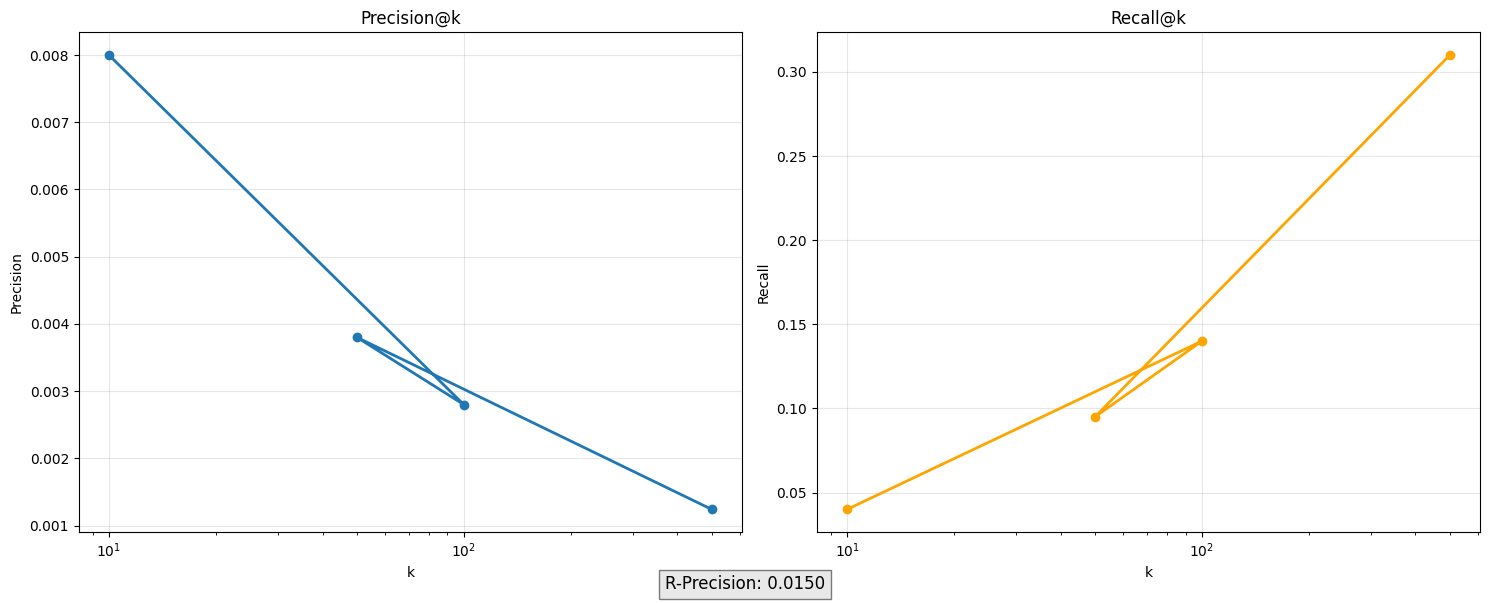

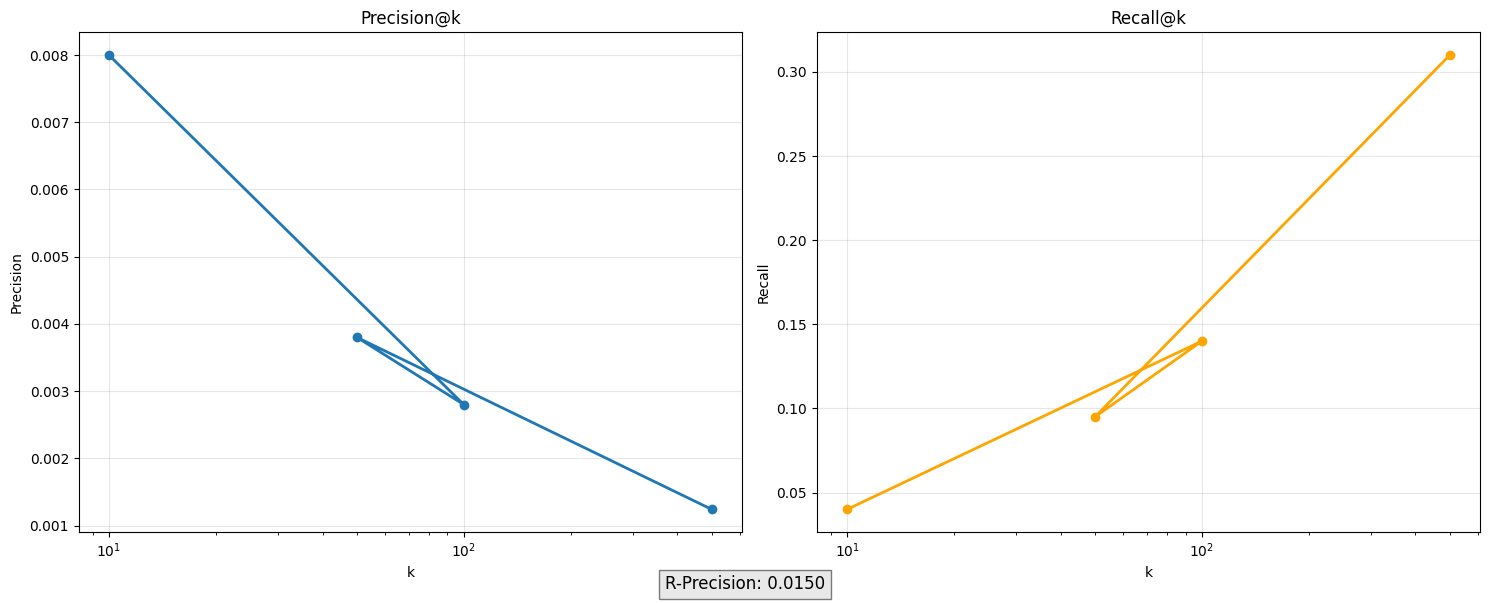

In [7]:
def plot_evaluation_results(results):
    """Plot evaluation results."""
    # Extract precision and recall values
    precision_metrics = sorted([k for k in results.keys() if k.startswith('precision')])
    recall_metrics = sorted([k for k in results.keys() if k.startswith('recall')])
    
    k_values = [int(k.split('@')[1]) for k in precision_metrics]
    precision_values = [results[k] for k in precision_metrics]
    recall_values = [results[k] for k in recall_metrics]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot precision@k
    ax1.plot(k_values, precision_values, 'o-', linewidth=2)
    ax1.set_xscale('log')
    ax1.set_title('Precision@k')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Precision')
    ax1.grid(True, alpha=0.3)
    
    # Plot recall@k
    ax2.plot(k_values, recall_values, 'o-', linewidth=2, color='orange')
    ax2.set_xscale('log')
    ax2.set_title('Recall@k')
    ax2.set_xlabel('k')
    ax2.set_ylabel('Recall')
    ax2.grid(True, alpha=0.3)
    
    # Add R-precision as text
    fig.text(0.5, 0.01, f"R-Precision: {results['r_precision']:.4f}", 
             ha='center', fontsize=12, bbox=dict(facecolor='lightgray', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot results
plot_evaluation_results(results)

In [8]:
def display_recommendations(model, playlist, n=10):
    """Show recommendations for a playlist with track names instead of URIs."""
    # Extract seed tracks
    seed_tracks = [track['track_uri'] for track in playlist['tracks']]
    
    # Get playlist name if available
    playlist_name = playlist.get('name', 'No Name')
    
    print(f"Playlist: {playlist_name}")
    print(f"Number of seed tracks: {len(seed_tracks)}")
    
    # Show seed tracks
    print("\nSeed tracks:")
    for i, track in enumerate(playlist['tracks'][:5]):  # Show first 5 seeds
        print(f"  {i+1}. {track['track_name']} by {track['artist_name']}")
    if len(playlist['tracks']) > 5:
        print(f"  ... and {len(playlist['tracks']) - 5} more")
    
    # Generate recommendations
    rec_uris = model.recommend_for_challenge(playlist, n=n)
    
    # Show recommendations with metadata
    print("\nRecommendations:")
    for i, uri in enumerate(rec_uris):
        if uri in model.track_metadata:
            track_info = model.track_metadata[uri]
            print(f"  {i+1}. {track_info['name']} by {track_info['artist']}")
        else:
            print(f"  {i+1}. {uri} (metadata not available)")

# Test with a few playlists
for i in range(3):  # Try 3 different playlists
    test_playlist = challenge_data['playlists'][i]
    display_recommendations(model, test_playlist)
    print("\n" + "-"*80 + "\n")

Playlist: spanish playlist
Number of seed tracks: 0

Seed tracks:

Recommendations:
  1. Fix You by Coldplay
  2. Springsteen by Eric Church
  3. Bounce Back by Big Sean
  4. Wagon Wheel by Darius Rucker
  5. Mr. Brightside by The Killers
  6. Started From the Bottom by Drake
  7. DNA. by Kendrick Lamar
  8. Chicken Fried by Zac Brown Band
  9. iSpy (feat. Lil Yachty) by KYLE
  10. Knee Deep (feat. Jimmy Buffett) by Zac Brown Band

--------------------------------------------------------------------------------

Playlist: Groovin
Number of seed tracks: 0

Seed tracks:

Recommendations:
  1. No Diggity by Blackstreet
  2. Empire State Of Mind by JAY Z
  3. Gettin' Jiggy Wit It by Will Smith
  4. White Iverson by Post Malone
  5. Neighbors Know My Name by Trey Songz
  6. Freek'n You by Jodeci
  7. You Got Me by The Roots
  8. On & On by Erykah Badu
  9. Tyrone - Live Version by Erykah Badu
  10. A Long Walk by Jill Scott

------------------------------------------------------------------